# Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# For all track, artist, distribution, and correlation analysis
tracks_df = pd.read_csv('../data/cleaned/tracks_deduped.csv')

# For all genre-specific grouping and visualization
genres_df = pd.read_csv('../data/cleaned/tracks_full.csv')

In [4]:
# Schema types
tracks_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 89741 entries, 0 to 89740
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89741 non-null  str    
 1   artists           89741 non-null  str    
 2   album_name        89741 non-null  str    
 3   track_name        89741 non-null  str    
 4   popularity        89741 non-null  int64  
 5   duration_ms       89741 non-null  int64  
 6   explicit          89741 non-null  bool   
 7   danceability      89741 non-null  float64
 8   energy            89741 non-null  float64
 9   key               89741 non-null  int64  
 10  loudness          89741 non-null  float64
 11  mode              89741 non-null  int64  
 12  speechiness       89741 non-null  float64
 13  acousticness      89741 non-null  float64
 14  instrumentalness  89741 non-null  float64
 15  liveness          89741 non-null  float64
 16  valence           89741 non-null  float64
 17  temp

In [5]:
genres_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           114000 non-null  str    
 2   album_name        114000 non-null  str    
 3   track_name        114000 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

## Descriptive Summary Statistics

In [6]:
# Numeric Values
print(tracks_df.describe())

         popularity   duration_ms  danceability        energy           key  \
count  89741.000000  8.974100e+04  89741.000000  89741.000000  89741.000000   
mean      33.207196  2.291418e+05      0.562166      0.634458      5.283549   
std       20.574270  1.129477e+05      0.176691      0.256605      3.559897   
min        0.000000  0.000000e+00      0.000000      0.000000      0.000000   
25%       19.000000  1.730400e+05      0.450000      0.457000      2.000000   
50%       33.000000  2.132930e+05      0.576000      0.676000      5.000000   
75%       49.000000  2.642930e+05      0.692000      0.853000      8.000000   
max      100.000000  5.237295e+06      0.985000      1.000000     11.000000   

           loudness          mode   speechiness  acousticness  \
count  89741.000000  89741.000000  89741.000000  89741.000000   
mean      -8.499004      0.636966      0.087442      0.328289   
std        5.221490      0.480877      0.113277      0.338321   
min      -49.531000      0.0

In [7]:
# Count the number of tracks per genre 
print(genres_df['track_genre'].value_counts())

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64


In [8]:
print(tracks_df['explicit'].value_counts())

explicit
False    82037
True      7704
Name: count, dtype: int64


## Spotting Nulls, Duplicates, Anomalies

In [9]:
# Missing Values per column
print(tracks_df.isnull().sum())

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
duration_min        0
is_live             0
is_instrumental     0
is_spoken_word      0
key_name            0
mode_name           0
dtype: int64


In [10]:
print(tracks_df.duplicated().sum())

0


In [11]:
# Count how many times the same 'track_id' is repeated in the raw dataset
print(tracks_df['track_id'].duplicated().sum()) 

0


## Visualizing Distributions and Outliers

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

### Plot 1: Popularity Distribution Histogram

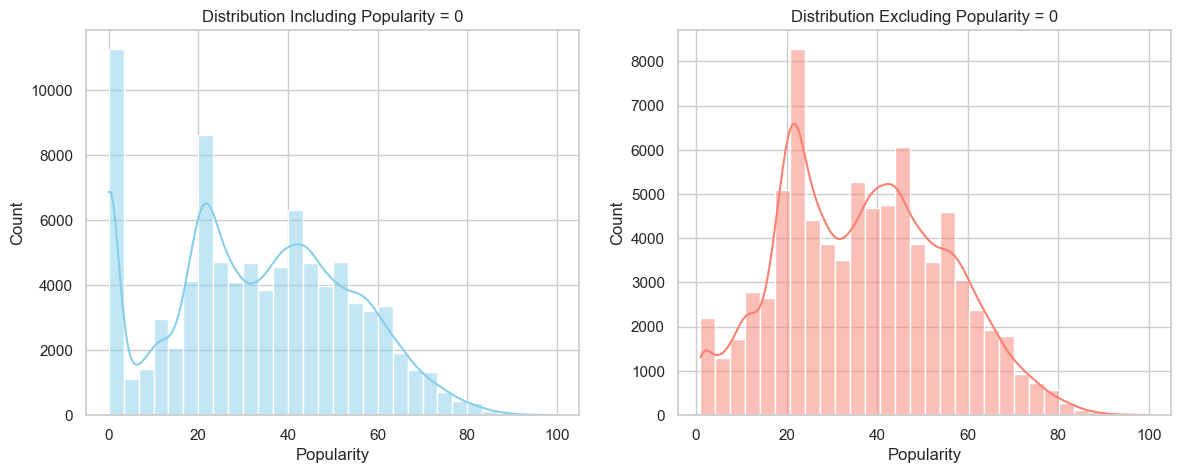

In [13]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_filtered = tracks_df[tracks_df['popularity'] > 0]
# Plot 1
sns.histplot(data=tracks_df, x='popularity', kde=True, bins=30, ax=axes[0], color="skyblue")
axes[0].set_title('Distribution Including Popularity = 0')
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Count')

# Plot 2: Excluding popularity=0
sns.histplot(data=df_filtered, x='popularity', bins=30, ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Distribution Excluding Popularity = 0')
axes[1].set_xlabel('Popularity')
axes[1].set_ylabel('Count')

plt.show()

### Plot 2: Spotting Audio Feature Outliers (Boxplots)

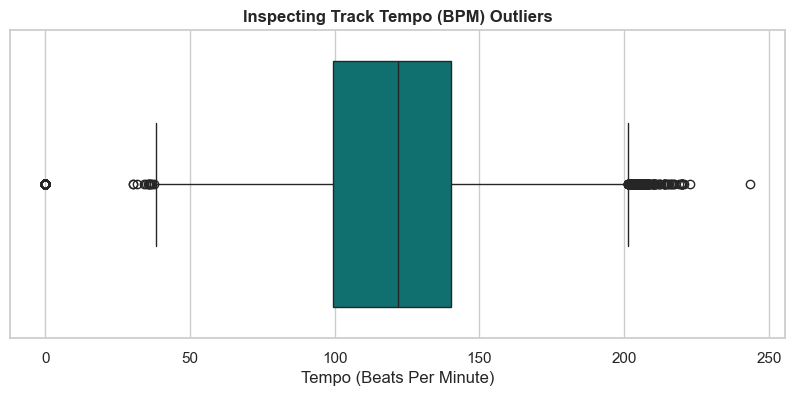

In [14]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=tracks_df, x='tempo', color="teal")

plt.title("Inspecting Track Tempo (BPM) Outliers", fontweight='bold')
plt.xlabel("Tempo (Beats Per Minute)")
plt.show()

## Plot 3: Exploring Relationships (Tempo VS Loudness)

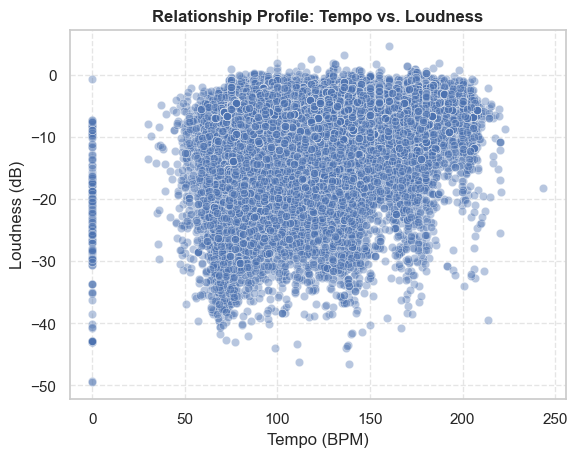

In [15]:
sns.scatterplot(data=tracks_df, x='tempo', y='loudness', alpha=0.4)

plt.title("Relationship Profile: Tempo vs. Loudness", fontsize=12, fontweight='bold')
plt.xlabel("Tempo (BPM)")
plt.ylabel("Loudness (dB)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Plot 4: Heatmap

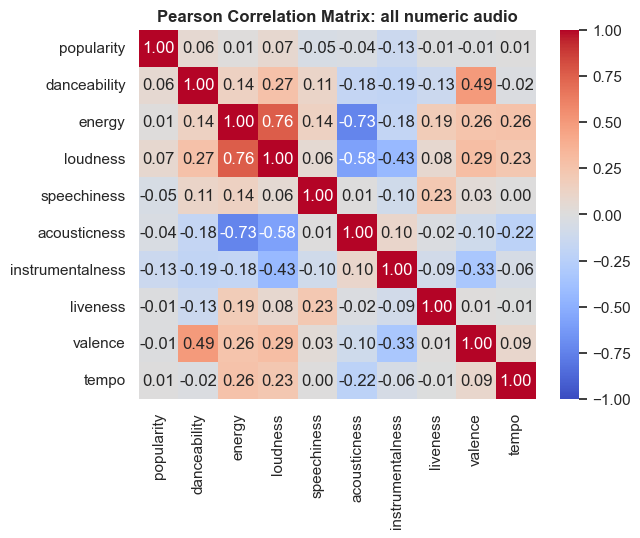

In [16]:
matrix = tracks_df[['popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']].corr()

sns.heatmap(data=matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix: all numeric audio", fontsize=12, fontweight='bold')
plt.show()

## Plot 5: Explicit vs Non-explicit

Text(0.5, 1.0, 'Explicit VS Non-explicit')

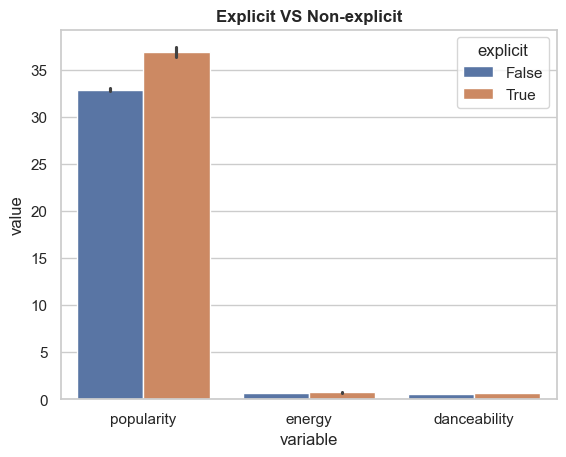

In [17]:
# Syntax for grouping and calculating multiple means
tracks_df.groupby('explicit')[['popularity', 'energy', 'danceability']].mean()

# Syntax for melting wide data to long data
melted_df = pd.melt(tracks_df, id_vars=['explicit'], value_vars=['popularity', 'energy', 'danceability'])

# Syntax for grouped bar plot
sns.barplot(data=melted_df, x='variable', y='value', hue='explicit')

plt.title("Explicit VS Non-explicit", fontweight='bold')

## Plot 6: Mode (Major vs Minor)

Text(0.5, 1.0, 'Major VS Minor')

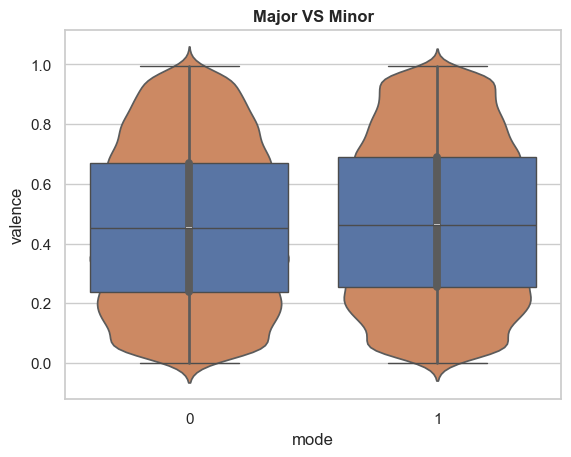

In [18]:
# Syntax to compare popularity across modes
tracks_df.groupby('mode')['popularity'].mean()


# Syntax for box plot
sns.boxplot(data=tracks_df, x='mode', y='valence')

# Syntax for violin plot
sns.violinplot(data=tracks_df, x='mode', y='valence')

plt.title("Major VS Minor", fontweight='bold')

## Zero-Popularity Phenomenon

In [19]:
tracks_0_sum = (tracks_df['popularity'] ==0).sum()
print(tracks_0_sum)

mean = (tracks_df['popularity']==0).mean() * 100
print(mean)

9348
10.416643451711035
